In [2]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import utils.label_mapping_utils as lmu


In [3]:
cell_type_colors = {
    # MSN subtypes (keeping original colors)
    'Matrix_D1': '#1f77b4',
    'Matrix_D2': '#6bb6d6',
    'Patch_D1': '#d62728',
    'Patch_D2': '#fa40fa',
    'eMSN_D1D2': '#f5ef41',
    'eMSN_StrioMat': '#16D416',
    'eMSN_NUDAP': '#8610da',
    'TAFA1': '#242554',
    
    # Non-MSN neurons
    'non-MSN': '#50d5f3',
    
    # Glia
    'Astrocyte': '#FFB6C1',  # Light pink - ADDED
    'Oligodendrocyte': '#FF8C00',  # Dark orange
    'OPC': '#FFA500',  # Orange
    'Ependymal': '#FFD700',  # Gold
    'Microglia': '#8B4513',  # Saddle brown
    
    # Vascular
    'Endothelial_BBB': '#2E8B57',  # Sea green
    'Pericytes': '#20B2AA',  # Light sea green
    'SmoothMuscleCells': '#5F9EA0',  # Cadet blue
    
    # Immune
    'Macrophages': '#DC143C',  # Crimson
    'COP': '#FF1493',  # Deep pink
    
    # Connective tissue
    'Fibroblasts': '#9370DB',  # Medium purple - ADDED
}

MSN_ct = ['Matrix_D1', 'Matrix_D2', 'Patch_D1', 'Patch_D2', 'eMSN_D1D2', 'eMSN_StrioMat', 'eMSN_NUDAP', 'TAFA1']

In [4]:
nucseq = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r")
slidetag = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured_aligned.h5ad", backed="r")

In [5]:
nucseq = nucseq[nucseq.obs['ct_for_deg'].notna()].to_memory().copy()
slidetag = slidetag[(slidetag.obs['ct_for_deg'].notna()) & (slidetag.obs['ct_for_deg'] != "nan")].to_memory().copy()

# Remove NA as a category
nucseq.obs['ct_for_deg'] = nucseq.obs['ct_for_deg'].cat.remove_unused_categories()
slidetag.obs['ct_for_deg'] = slidetag.obs['ct_for_deg'].cat.remove_unused_categories()

In [6]:
nucseq.obs['ct_for_deg'] = nucseq.obs['ct_for_deg'].map({"-TAFA1": "TAFA1"}).fillna(nucseq.obs['ct_for_deg']).astype('category')
slidetag.obs['ct_for_deg'] = slidetag.obs['ct_for_deg'].map({"-TAFA1": "TAFA1"}).fillna(slidetag.obs['ct_for_deg']).astype('category')

nucseq.obs["matrix_vs_patch"] = nucseq.obs["ct_for_deg"].map({
    "Matrix_D1": "Matrix",
    "Matrix_D2": "Matrix",
    "Patch_D1": "Patch",
    "Patch_D2": "Patch",
})

nucseq.obs["D1_vs_D2"] = nucseq.obs["ct_for_deg"].map({
    "Matrix_D1": "D1",
    "Matrix_D2": "D2",
    "Patch_D1": "D1",
    "Patch_D2": "D2",
})

slidetag.obs["matrix_vs_patch"] = slidetag.obs["ct_for_deg"].map({
    "Matrix_D1": "Matrix",
    "Matrix_D2": "Matrix",
    "Patch_D1": "Patch",
    "Patch_D2": "Patch",
})

slidetag.obs["D1_vs_D2"] = slidetag.obs["ct_for_deg"].map({
    "Matrix_D1": "D1",
    "Matrix_D2": "D2",
    "Patch_D1": "D1",
    "Patch_D2": "D2",
})

In [7]:


ct_to_plot_nucseq = list(set(nucseq.obs['ct_for_deg'].cat.categories).intersection(set(nucseq.obs['ct_for_deg'][~nucseq.obs['ct_for_deg'].str.startswith("-")])))
ct_to_plot_slidetag = list(set(slidetag.obs['ct_for_deg'].cat.categories).intersection(set(slidetag.obs['ct_for_deg'][~slidetag.obs['ct_for_deg'].str.startswith("-")])))

ct_to_plot = list(set(ct_to_plot_nucseq).intersection(set(ct_to_plot_slidetag)))
ct_to_plot.append("TAFA1")
ct_to_plot




# Get all unique cell types in the data
all_cell_types_nucseq = nucseq.obs['ct_for_deg'].cat.categories.tolist()
all_cell_types_slidetag = slidetag.obs['ct_for_deg'].cat.categories.tolist()
 
# Create color dict with defaults for any cell type not in our palette
def get_palette_for_data(all_cell_types, custom_colors):
    palette = {}
    for ct in all_cell_types:
        if ct in custom_colors:
            palette[ct] = custom_colors[ct]
        else:
            palette[ct] = '#cccccc'  # Gray default for unspecified types
    return palette
 
palette_nucseq = get_palette_for_data(all_cell_types_nucseq, cell_type_colors)
palette_slidetag = get_palette_for_data(all_cell_types_slidetag, cell_type_colors)
 
# Store in the adata objects
nucseq.uns['ct_for_deg_colors'] = [palette_nucseq[ct] for ct in all_cell_types_nucseq]
slidetag.uns['ct_for_deg_colors'] = [palette_slidetag[ct] for ct in all_cell_types_slidetag]

In [15]:
ct_to_plot

['Matrix_D1',
 'Patch_D2',
 'OPC',
 'Endothelial_BBB',
 'SmoothMuscleCells',
 'Matrix_D2',
 'eMSN_NUDAP',
 'eMSN_D1D2',
 'eMSN_StrioMat',
 'Patch_D1',
 'Pericytes',
 'Ependymal',
 'Oligodendrocyte',
 'non-MSN',
 'Microglia',
 'Fibroblasts',
 'COP',
 'Astrocyte',
 'TAFA1',
 'Macrophages',
 'TAFA1']

# Umap ALL cell types Nucseq + SlideTag

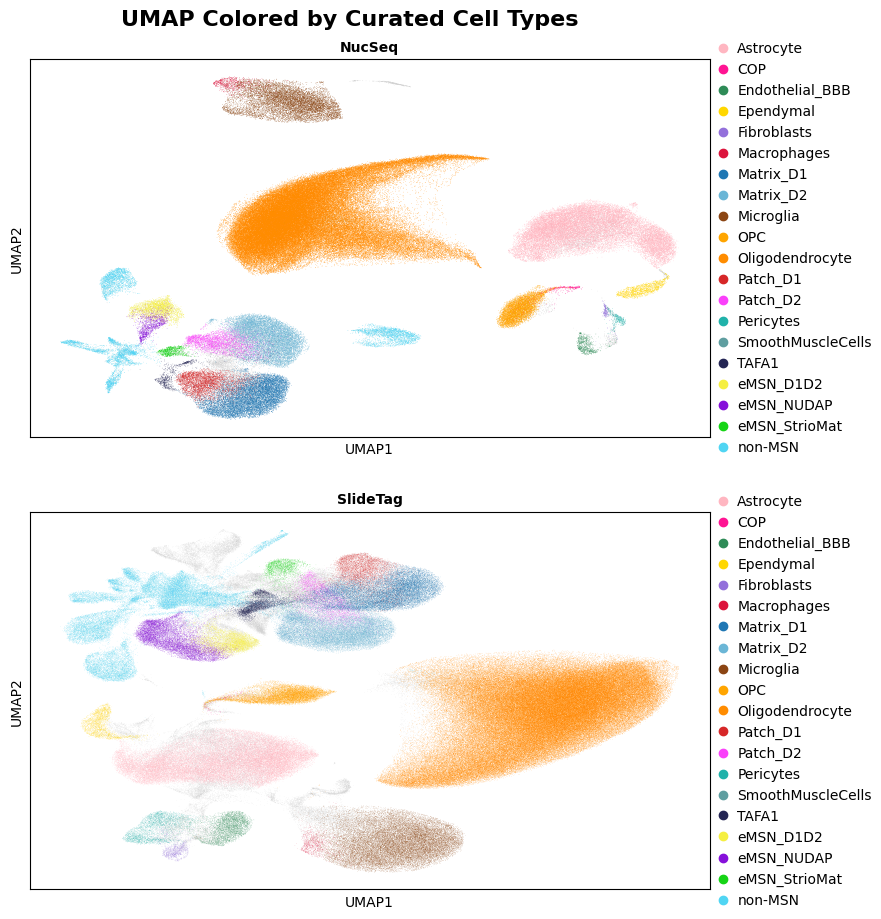

In [53]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))
 
# NucSeq
sc.pl.embedding(
    nucseq,
    basis='umap',
    color='ct_for_deg',
    ax=ax[0],
    groups=ct_to_plot,
    show=False,
    frameon=True,
    #legend_loc="on data"
)
ax[0].set_title("NucSeq", fontsize=10, fontweight='bold')
 
# SlideTag
sc.pl.embedding(
    slidetag,
    basis='umap',
    color='ct_for_deg',
    ax=ax[1],
    groups=ct_to_plot,
    show=False,
    frameon=True,
)
ax[1].set_title("SlideTag", fontsize=10, fontweight='bold')
 
fig.suptitle(
    "UMAP Colored by Curated Cell Types",
    fontsize=16,
    fontweight='bold',
    y=0.98
)

# Make the plot boxes wider
plt.subplots_adjust(left=0.1, right=0.95, top=0.93, bottom=0.1)
# Adjust left/right values to control horizontal width
# smaller left = wider | smaller right = wider

#Remove NA from legends
for axes in ax:
    handles, labels = axes.get_legend_handles_labels()
    new_handles = [h for h, label in zip(handles, labels) if label != 'NA']
    new_labels = [label for label in labels if label != 'NA']
    axes.legend(handles=new_handles, labels=new_labels, 
                loc='center left', bbox_to_anchor=(1, 0.5))

# plt.savefig("./img/umap_nucseq_slidetag.pdf", dpi=300, bbox_inches='tight')
plt.savefig("./img/umap_nucseq_slidetag.png", dpi=300, bbox_inches='tight')
plt.show()

=== Stacked composition ===


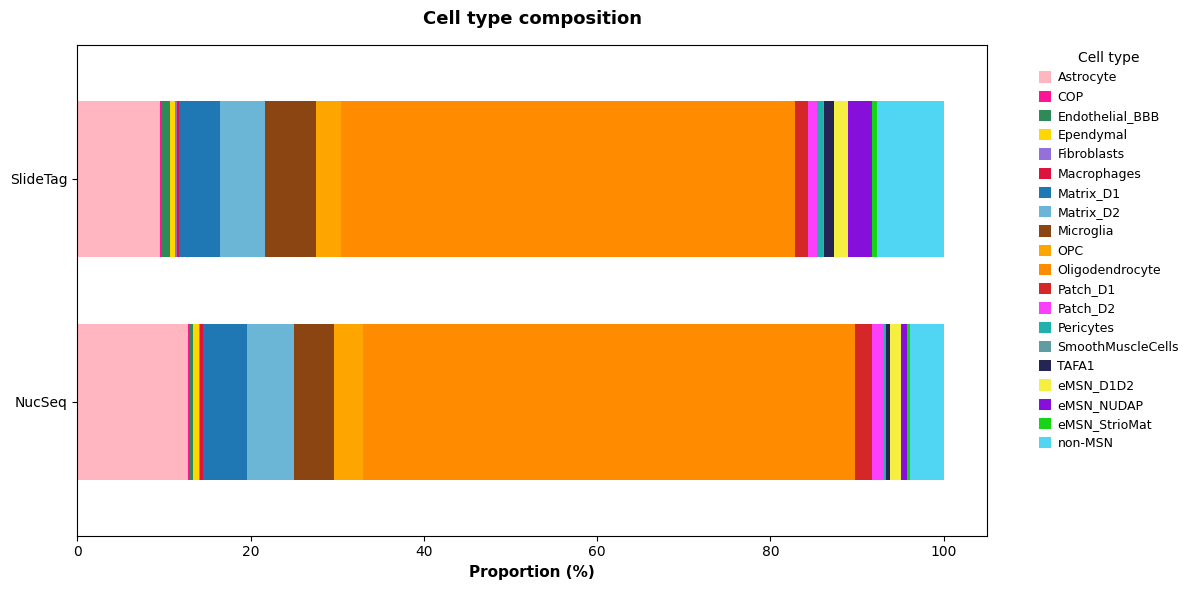

In [80]:

# ============================================================================
# CELL TYPE PROPORTIONS - ONLY FOR CELLS IN cell_type_colors
# ============================================================================
def get_celltype_proportions(adata, dataset_name, group_by=None):
    """
    Calculate cell type proportions - ONLY for cell types in cell_type_colors.
    """
    ct = adata.obs["ct_for_deg"].astype(str)
    ct = ct[ct.notna() & (~ct.str.startswith("-")) & (ct != "nan")]
    
    # Filter to only cell types in cell_type_colors
    ct = ct[ct.isin(cell_type_colors.keys())]
    
    if group_by is None:
        prop = ct.value_counts(normalize=True).mul(100).rename("proportion_pct")
        df = prop.rename_axis("cell_type").reset_index()
        df["dataset"] = dataset_name
        return df
    else:
        groups = adata.obs.loc[ct.index, group_by].astype(str)
        dfs = []
        for group in groups.unique():
            mask = (groups == group)
            ct_subset = ct[mask]
            prop = ct_subset.value_counts(normalize=True).mul(100).rename("proportion_pct")
            df = prop.rename_axis("cell_type").reset_index()
            df["dataset"] = dataset_name
            df[group_by] = group
            dfs.append(df)
        return pd.concat(dfs, ignore_index=True)
 
 
# ============================================================================
# STACKED BAR PLOT
# ============================================================================
def plot_stacked_composition(
    adata_list,
    dataset_names,
    group_by=None,
    figsize=(12, 6)
):
    """Stacked bar plot using cell_type_colors palette."""
    
    dfs = [
        get_celltype_proportions(adata, name, group_by=group_by)
        for adata, name in zip(adata_list, dataset_names)
    ]
    prop_df = pd.concat(dfs, ignore_index=True)
    
    if group_by is None:
        pivot_df = prop_df.pivot(index="dataset", columns="cell_type", values="proportion_pct").fillna(0)
    else:
        pivot_df = prop_df.pivot_table(
            index=[group_by, "dataset"], 
            columns="cell_type", 
            values="proportion_pct",
            aggfunc='first'
        ).fillna(0)
    
    # Use cell_type_colors for bar colors
    colors = [cell_type_colors.get(ct, '#cccccc') for ct in pivot_df.columns]
    
    fig, ax = plt.subplots(figsize=figsize)
    pivot_df.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=colors,
        width=0.7,
    )
    
    ax.set_xlabel("Proportion (%)", fontsize=11, fontweight="bold")
    ax.set_ylabel("", fontsize=11)
    ax.legend(title="Cell type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.set_title("Cell type composition", fontsize=13, fontweight="bold", pad=15)
    
    plt.tight_layout()
    plt.savefig("./img/cell_type_composition_stacked_bar.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    return prop_df
 
 
 
# ============================================================================
# USAGE
# ============================================================================
 
# Stacked bar
print("=== Stacked composition ===")
prop_stacked = plot_stacked_composition(
    [nucseq, slidetag],
    ["NucSeq", "SlideTag"]
)
 


# Umap MSN Only Nucseq + Slidetag

In [17]:
nucseq_msn = nucseq[nucseq.obs['ct_for_deg'].isin(MSN_ct)].copy()
slidetag_msn = slidetag[slidetag.obs['ct_for_deg'].isin(MSN_ct)].copy()

In [ ]:
print(f"NucSeq MSN subset: {nucseq_msn.n_obs} cells")
print(f"SlideTag MSN subset: {slidetag_msn.n_obs} cells")
 
for adata, batch_key in zip([nucseq_msn, slidetag_msn], ["donor_id", "sample"]):
    if batch_key=="donor_id":
        continue
    leiden_nucseq = lmu.preprocess_common_pipeline(
        adata,
        umap_name="_msn",           # Names the UMAP X_umap_msn
        leiden_name="_msn",         # Names clusters leiden_0.1_msn, etc.
        resolutions=[10],
        integrate_with_harmony=True,
        batch_key=batch_key
    )

slidetag_msn.var.index = slidetag_msn.var["gene_symbol"].astype(str)
slidetag_msn.var_names_make_unique()

nucseq_msn.to_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned_just_MSN.h5ad")
slidetag_msn.to_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/adatas/Striatum/SlideTag_combined_QC_mmc_ct-cured_zoned_just_MSN.h5ad")

Seed set to 42


NucSeq MSN subset: 36130 cells
SlideTag MSN subset: 86645 cells
Running HVG...
HVG computed with batch_key='sample'
Subsetting to copy with only HVG...
Scaling ...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Running Harmony...
Running PCA before Harmony...


2026-07-28 11:08:31,580 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-07-28 11:08:31 | [INFO] Running Harmony (PyTorch on cuda)
2026-07-28 11:08:31,582 - harmonypy - INFO -   Parameters:
2026-07-28 11:08:31 | [INFO]   Parameters:
2026-07-28 11:08:31,582 - harmonypy - INFO -     max_iter_harmony: 30
2026-07-28 11:08:31 | [INFO]     max_iter_harmony: 30
2026-07-28 11:08:31,583 - harmonypy - INFO -     max_iter_kmeans: 20
2026-07-28 11:08:31 | [INFO]     max_iter_kmeans: 20
2026-07-28 11:08:31,584 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-07-28 11:08:31 | [INFO]     epsilon_cluster: 1e-05
2026-07-28 11:08:31,585 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-07-28 11:08:31 | [INFO]     epsilon_harmony: 0.0001
2026-07-28 11:08:31,586 - harmonypy - INFO -     nclust: 100
2026-07-28 11:08:31 | [INFO]     nclust: 100
2026-07-28 11:08:31,587 - harmonypy - INFO -     block_size: 0.05
2026-07-28 11:08:31 | [INFO]     block_size: 0.05
2026-07-28 11:08:31,588 - harm

Running Harmony batch correction...


2026-07-28 11:08:32,403 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-28 11:08:32 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-07-28 11:08:34,299 - harmonypy - INFO - KMeans initialization complete.
2026-07-28 11:08:34 | [INFO] KMeans initialization complete.
2026-07-28 11:08:34,698 - harmonypy - INFO - Iteration 1 of 30
2026-07-28 11:08:34 | [INFO] Iteration 1 of 30
2026-07-28 11:08:35,482 - harmonypy - INFO - Iteration 2 of 30
2026-07-28 11:08:35 | [INFO] Iteration 2 of 30
2026-07-28 11:08:36,066 - harmonypy - INFO - Iteration 3 of 30
2026-07-28 11:08:36 | [INFO] Iteration 3 of 30
2026-07-28 11:08:36,603 - harmonypy - INFO - Iteration 4 of 30
2026-07-28 11:08:36 | [INFO] Iteration 4 of 30
2026-07-28 11:08:37,032 - harmonypy - INFO - Iteration 5 of 30
2026-07-28 11:08:37 | [INFO] Iteration 5 of 30
2026-07-28 11:08:37,563 - harmonypy - INFO - Iteration 6 of 30
2026-07-28 11:08:37 | [INFO] Iteration 6 of 30
2026-07-28 11:08:37,956 - 

Z_corr shape: (86645, 50), n_obs: 86645
Computing neighbors on Harmony-corrected PCA...
Computing UMAP...
Computing Leiden clusters...


NameError: name 'msn' is not defined

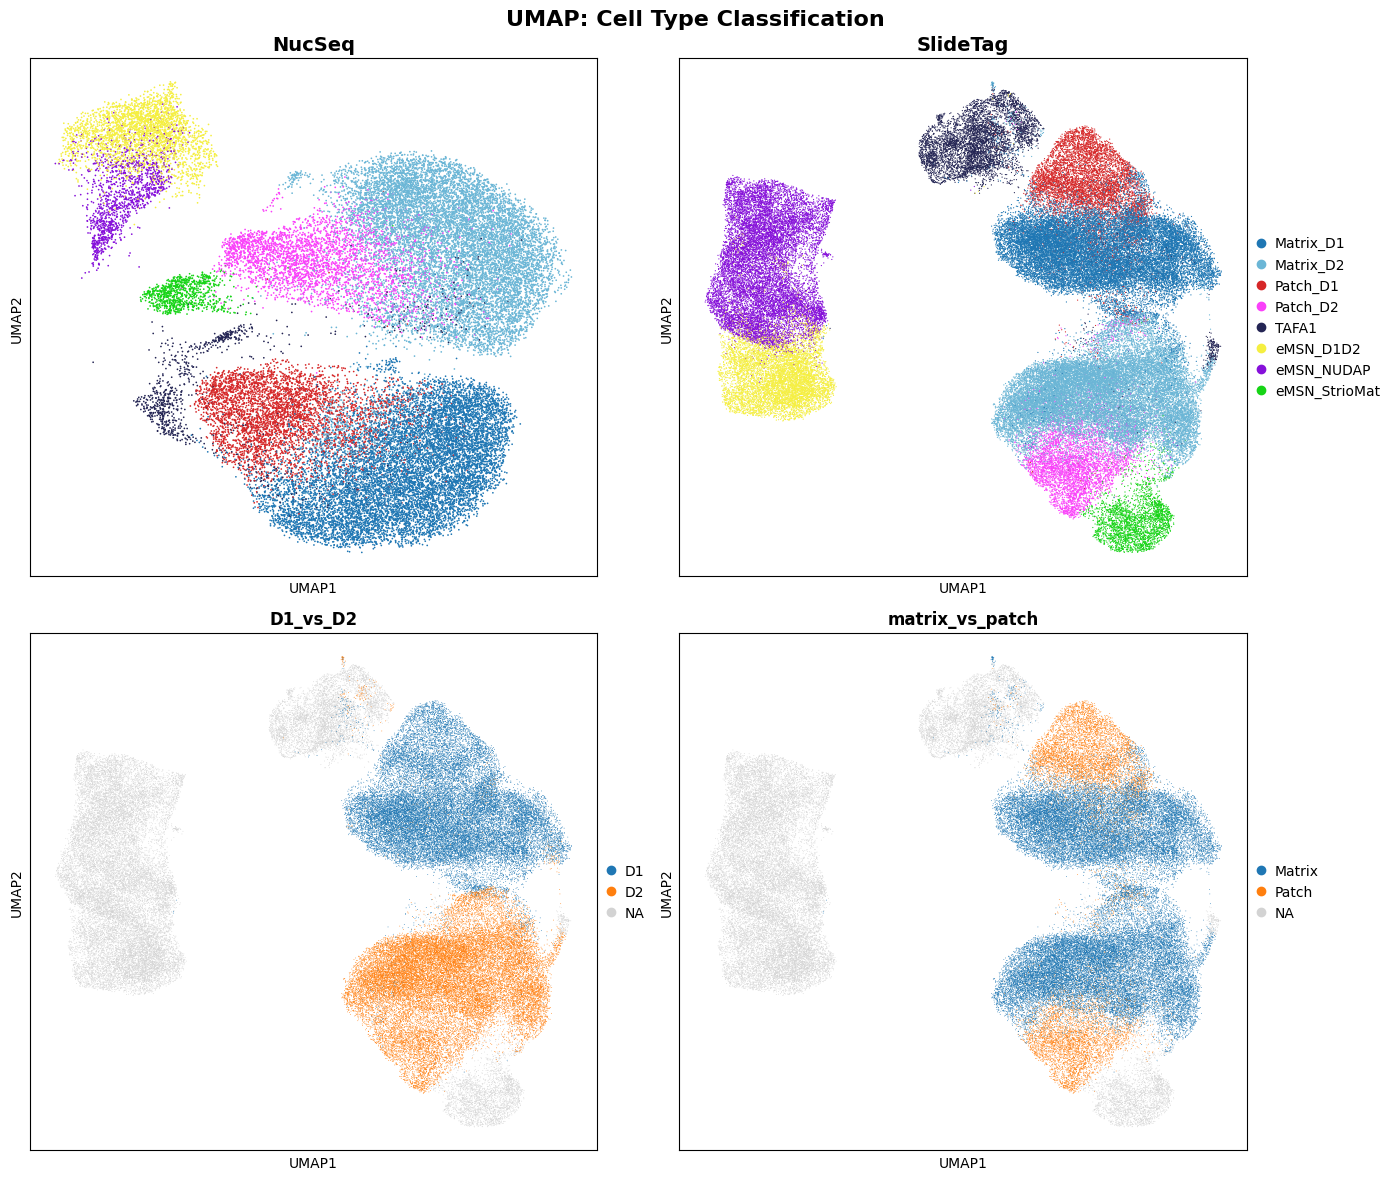

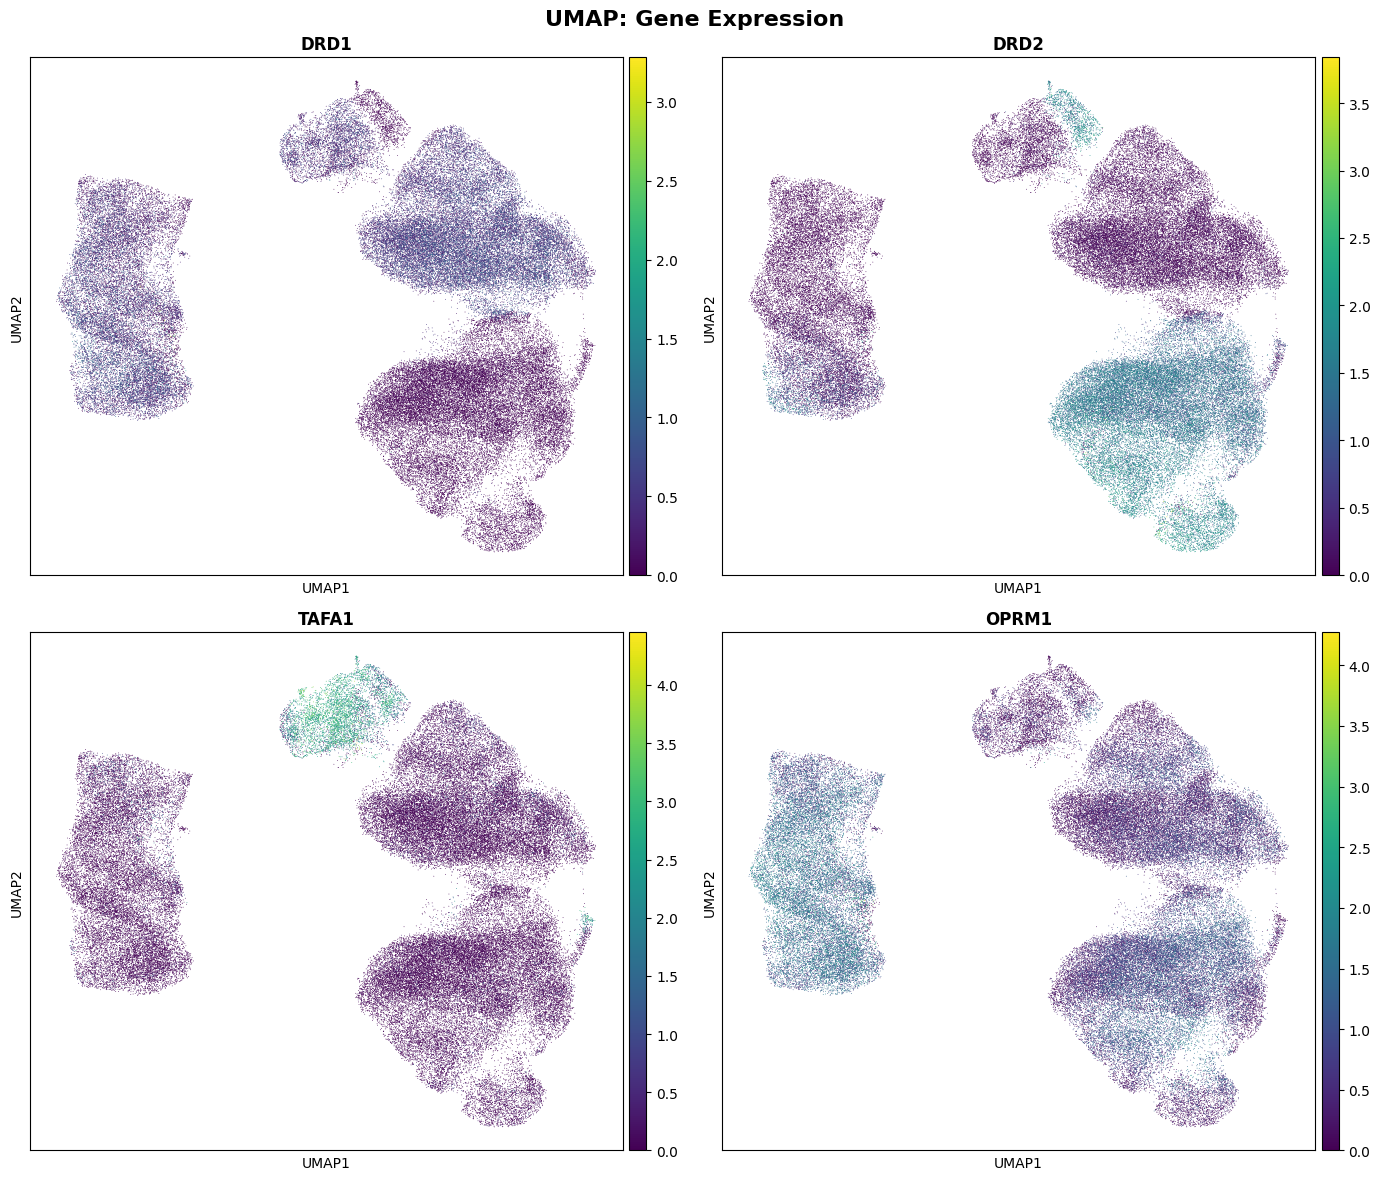

In [58]:
import matplotlib.pyplot as plt
import scanpy as sc

# ============ FIGURE 1: Cell Type Classification ============
fig1, ax1 = plt.subplots(2, 2, figsize=(14, 12))

# Row 0: NucSeq and SlideTag
sc.pl.embedding(
    nucseq_msn,
    basis='umap',
    color='ct_for_deg',
    ax=ax1[0, 0],
    groups=ct_to_plot,
    show=False,
    frameon=True,
    size=6,
    legend_loc=None
)
ax1[0, 0].set_title("NucSeq", fontsize=14, fontweight='bold')

sc.pl.embedding(
    slidetag_msn,
    basis='umap',
    color='ct_for_deg',
    ax=ax1[0, 1],
    groups=ct_to_plot,
    show=False,
    frameon=True,
    size=3,
)
ax1[0, 1].set_title("SlideTag", fontsize=14, fontweight='bold')

# Row 1: D1_vs_D2 and matrix_vs_patch
sc.pl.embedding(
    slidetag_msn,
    basis='umap',
    color="D1_vs_D2",
    ax=ax1[1, 0],
    show=False,
    frameon=True,
)
ax1[1, 0].set_title("D1_vs_D2", fontsize=12, fontweight='bold')

sc.pl.embedding(
    slidetag_msn,
    basis='umap',
    color="matrix_vs_patch",
    ax=ax1[1, 1],
    show=False,
    frameon=True,
)
ax1[1, 1].set_title("matrix_vs_patch", fontsize=12, fontweight='bold')

fig1.suptitle("UMAP: Cell Type Classification", fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig("./img/umap_cell_types.pdf", dpi=300, bbox_inches='tight')
plt.savefig("./img/umap_cell_types.png", dpi=300, bbox_inches='tight')
plt.show()

# ============ FIGURE 2: Gene Expression ============
fig2, ax2 = plt.subplots(2, 2, figsize=(14, 12))
ax2 = ax2.flatten()

genes = ["DRD1", "DRD2", "TAFA1", "OPRM1"]
for idx, gene in enumerate(genes):
    sc.pl.embedding(
        slidetag_msn,
        basis='umap',
        color=gene,
        ax=ax2[idx],
        show=False,
        frameon=True,
        layer="log1p_norm"
    )
    ax2[idx].set_title(f"{gene}", fontsize=12, fontweight='bold')

fig2.suptitle("UMAP: Gene Expression", fontsize=16, fontweight='bold')
plt.tight_layout()
# plt.savefig("./img/umap_gene_expression.pdf", dpi=300, bbox_inches='tight')
plt.savefig("./img/umap_gene_expression.png", dpi=300, bbox_inches='tight')
plt.show()

Cell types: ['Matrix_D1', 'Matrix_D2', 'Patch_D1', 'Patch_D2', 'TAFA1']
Markers: ['DRD1', 'TAC1', 'DRD1', 'TAC1', 'DRD2', 'PENK', 'DRD2', 'PENK', 'TAFA1']

SlideTag subset: 63413 cells
Cell type distribution:
ct_for_deg
Matrix_D2    24113
Matrix_D1    21964
Patch_D1      6813
TAFA1         5594
Patch_D2      4929
Name: count, dtype: int64
Plotting 9 genes


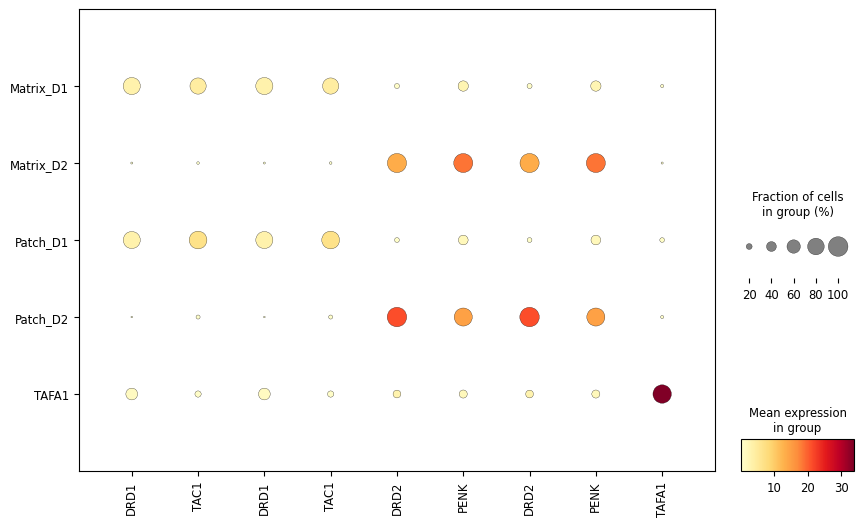

<Figure size 640x480 with 0 Axes>

In [60]:
import scanpy as sc
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

# ============================================================================
# CELL TYPES AND MARKERS
# ============================================================================
cell_types = ['Matrix_D1', 'Matrix_D2', "Patch_D1", "Patch_D2", 'TAFA1']

markers = {
    'D1 Matrix': ['DRD1', 'TAC1'],
    'D1 Patch': ['DRD1', 'TAC1'],
    'D2 Matrix': ['DRD2', 'PENK'],
    'D2 Patch': ['DRD2', 'PENK'],
    'TAFA1': ['TAFA1'],
}

# Flatten markers to list
marker_genes = [gene for genes in markers.values() for gene in genes]

print(f"Cell types: {cell_types}")
print(f"Markers: {marker_genes}")

# ============================================================================
# SUBSET SLIDETAG
# ============================================================================
slidetag_subset = slidetag[slidetag.obs['ct_for_deg'].isin(cell_types)].copy()

slidetag_subset.var.index = slidetag_subset.var["gene_symbol"].astype(str)
slidetag_subset.var_names_make_unique()

print(f"\nSlideTag subset: {slidetag_subset.n_obs} cells")
print(f"Cell type distribution:")
print(slidetag_subset.obs['ct_for_deg'].value_counts())

# ============================================================================
# SET CELL TYPE ORDER
# ============================================================================
# Convert to categorical with specified order
cat_type = CategoricalDtype(categories=cell_types, ordered=True)
slidetag_subset.obs['ct_for_deg'] = slidetag_subset.obs['ct_for_deg'].astype(cat_type)

# ============================================================================
# DOT PLOT
# ============================================================================
# Make sure genes exist in data
available_genes = [g for g in marker_genes if g in slidetag_subset.var_names]
missing_genes = [g for g in marker_genes if g not in slidetag_subset.var_names]

if missing_genes:
    print(f"\nWarning: genes not found in data: {missing_genes}")

print(f"Plotting {len(available_genes)} genes")

sc.pl.dotplot(
    slidetag_subset,
    var_names=available_genes,
    groupby='ct_for_deg',
    figsize=(10, 6),
    dendrogram=False,
    color_map='YlOrRd',
    dot_max=1.0,
    dot_min=0.0,
)

plt.suptitle('Marker gene expression across cell types', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("./img/marker_dotplot_slidetag.pdf", dpi=300, bbox_inches='tight')
plt.show()

Cell types: ['Matrix_D1', 'Patch_D1', 'Matrix_D2', 'Patch_D2', 'eMSN_StrioMat']
Markers: ['TAC1', 'VGF', 'CALCA', 'PENK', 'TAFA1', 'BDNF']

SlideTag compartment subset: 60459 cells
Cell type distribution:
ct_for_deg
Matrix_D2        24113
Matrix_D1        21964
Patch_D1          6813
Patch_D2          4929
eMSN_StrioMat     2640
Name: count, dtype: int64
Plotting 6 genes


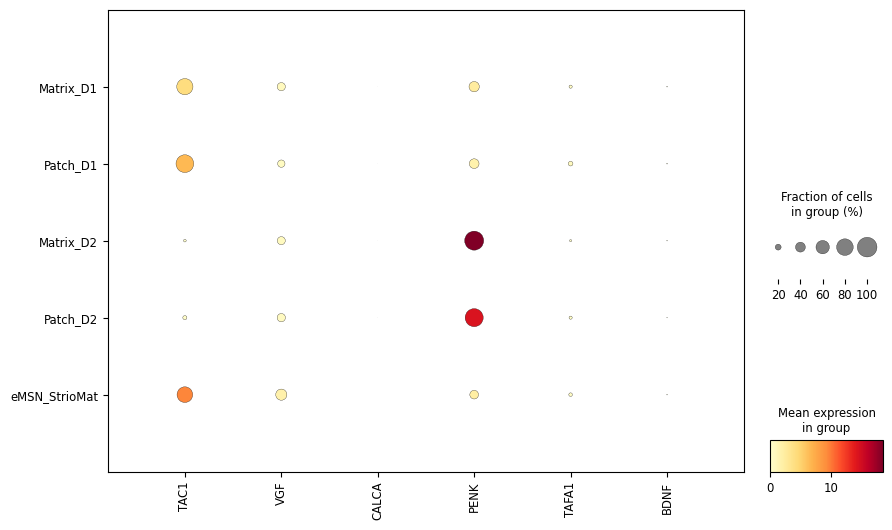

<Figure size 640x480 with 0 Axes>

In [70]:
import scanpy as sc
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype

# ============================================================================
# CELL TYPES AND MARKERS - MATRIX vs PATCH COMPARTMENTS
# ============================================================================
cell_types_compartment = ['Matrix_D1', "Patch_D1",'Matrix_D2', "Patch_D2", "eMSN_StrioMat"]

# Well-established striatal compartment markers
markers_compartment = {
    'Matrix markers': ['TAC1', 'VGF', 'CALCA'],      # Substance P, VGF, CGRP
    'Patch markers': ['PENK', 'TAFA1', 'BDNF'],      # Enkephalin, TAFA1, BDNF
}

# Flatten markers to list
marker_genes_comp = [gene for genes in markers_compartment.values() for gene in genes]

print(f"Cell types: {cell_types_compartment}")
print(f"Markers: {marker_genes_comp}")

# ============================================================================
# SUBSET SLIDETAG - ONLY MATRIX AND PATCH
# ============================================================================
slidetag_comp = slidetag[slidetag.obs['ct_for_deg'].isin(cell_types_compartment)].copy()

slidetag_comp.var.index = slidetag_comp.var["gene_symbol"].astype(str)
slidetag_comp.var_names_make_unique()

print(f"\nSlideTag compartment subset: {slidetag_comp.n_obs} cells")
print(f"Cell type distribution:")
print(slidetag_comp.obs['ct_for_deg'].value_counts())

# ============================================================================
# SET CELL TYPE ORDER
# ============================================================================
cat_type = CategoricalDtype(categories=cell_types_compartment, ordered=True)
slidetag_comp.obs['ct_for_deg'] = slidetag_comp.obs['ct_for_deg'].astype(cat_type)

# ============================================================================
# DOT PLOT - MATRIX vs PATCH MARKERS
# ============================================================================
available_genes = [g for g in marker_genes_comp if g in slidetag_comp.var_names]
missing_genes = [g for g in marker_genes_comp if g not in slidetag_comp.var_names]

if missing_genes:
    print(f"\nWarning: genes not found in data: {missing_genes}")

print(f"Plotting {len(available_genes)} genes")

sc.pl.dotplot(
    slidetag_comp,
    var_names=available_genes,
    groupby='ct_for_deg',
    figsize=(10, 6),
    dendrogram=False,
    color_map='YlOrRd',
    dot_max=1.0,
    dot_min=0.0,
)

plt.suptitle('Striatal compartment markers: Matrix vs Patch MSNs', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("./img/marker_dotplot_compartments.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Slidetag MSN Dotplot Marker genes

In [58]:
slidetag_msn_mp = slidetag_msn[slidetag_msn.obs["ct_for_deg"].isin(["Matrix_D1", "Matrix_D2", "Patch_D1", "Patch_D2"])].copy()

# Slidetag - Matrix Patch Images

In [ ]:
sample_01 = slidetag[(slidetag.obs['sample'] == 'sample_01') & (slidetag.obs['ct_for_deg'].isin(MSN_ct)) ].copy()
sample_09 = slidetag[(slidetag.obs['sample'] == 'sample_09') & (slidetag.obs['ct_for_deg'].isin(MSN_ct)) & (slidetag.obs['matrix_vs_patch'].notna())].copy()


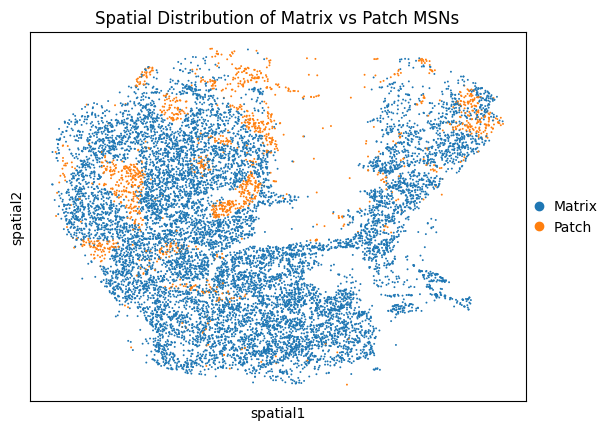

In [78]:

sc.pl.embedding(
    sample_09,
    basis='spatial',
    color=["matrix_vs_patch"],
    show=False,
    frameon=True,
    ncols=2
    #size=100,
)
plt.title("Spatial Distribution of Matrix vs Patch MSNs")
plt.savefig("./img/spatial_matrix_vs_patch_sample_09.png", dpi=300, bbox_inches='tight')

<Axes: title={'center': 'matrix_vs_patch'}, xlabel='spatial1', ylabel='spatial2'>

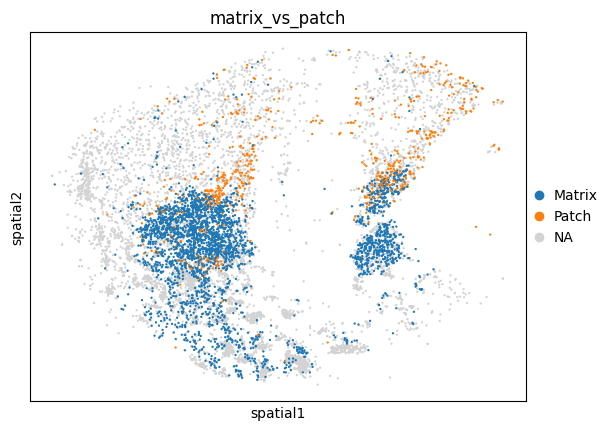

In [85]:
sample_01 = slidetag[(slidetag.obs['sample'] == 'sample_01') & (slidetag.obs['ct_for_deg'].isin(MSN_ct)) ].copy()
sc.pl.embedding(
    sample_01,
    basis='spatial',
    color=["matrix_vs_patch"],
    show=False,
    frameon=True,
    ncols=2
    #size=100,
)

# Bican

In [25]:
b_matrix = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/Matrix_D1.h5ad")
d1d2_matrix = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/bican_spatial_zonated/eMSN_D1D2.h5ad")


# normalise and log-normalise
sc.pp.normalize_total(b_matrix, target_sum=1e4)
sc.pp.log1p(b_matrix)

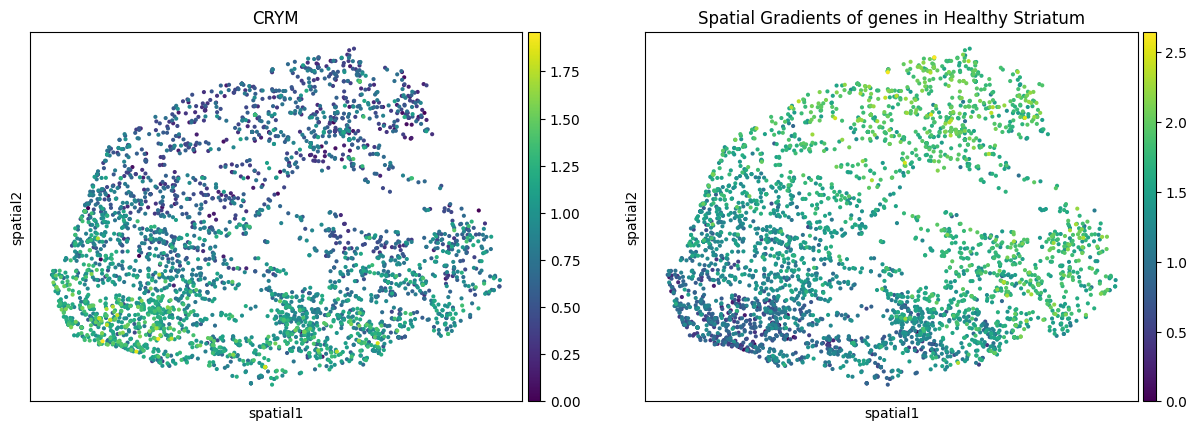

In [13]:
b_matrix_s1 = b_matrix[b_matrix.obs['donor_id'] == 's5'].to_memory().copy()
d1d2_matrix_s1 = d1d2_matrix[d1d2_matrix.obs['donor_id'] == 's5'].to_memory().copy()


sc.pl.embedding(
    b_matrix_s1,
    basis='spatial',
    color=["CRYM", "CNR1"],
    show=False,
    frameon=True,
    ncols=2
    #size=100,
)
plt.title("Spatial Gradients of genes in Healthy Striatum")
plt.savefig("./img/spatial_gradients_healthy_striatum.png", dpi=300, bbox_inches='tight')

In [18]:
d1d2_matrix_s1

AnnData object with n_obs × n_vars = 510 × 37905
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'donor_external_id', 'is_primary_data', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'donor_id', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'x', 'y', 'RNA_snn_res.0.8', 'seurat_clusters', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'AK_celltype', 'RNA_snn_res.0.2', 'cb', 'clusters', 'num_dbscan', 'logu

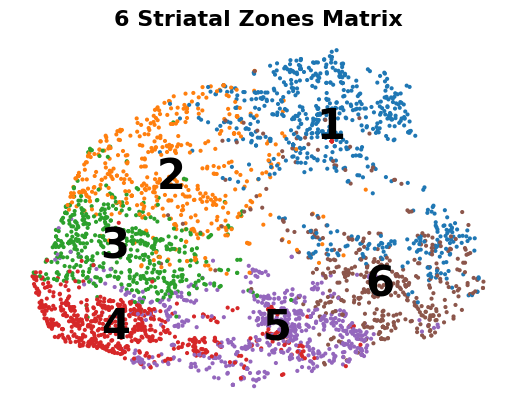

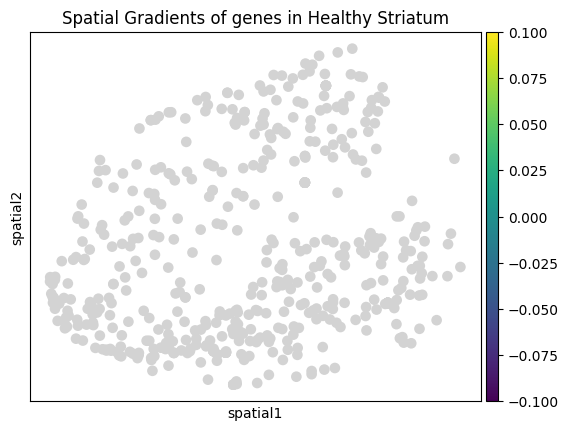

In [33]:
sc.pl.embedding(
    b_matrix_s1,
    basis='spatial',
    color="zone",
    show=False,
    frameon=False,      # Removes both the frames and the axis names
    ncols=2,
    #size=100,
    legend_loc="on data",
    legend_fontsize=30  # Replaces 'textsi' to adjust legend text size
)
plt.title("6 Striatal Zones Matrix", fontsize=16, fontweight='bold')

sc.pl.embedding(
    d1d2_matrix_s1,
    basis='spatial',
    color="zones_4",
    show=False,
    frameon=True,
    ncols=2
    #size=100,
)
plt.title("4 Striatal Zones eMSN D1D2", fontsize=16, fontweight='bold')
plt.title("Spatial Gradients of genes in Healthy Striatum")
plt.savefig("./img/spatial_gradients_healthy_striatum.png", dpi=300, bbox_inches='tight')

# DEG bias

Healthy: 3396 cells
Disease (CRYM >= 50th percentile = 0.829): 1698 cells


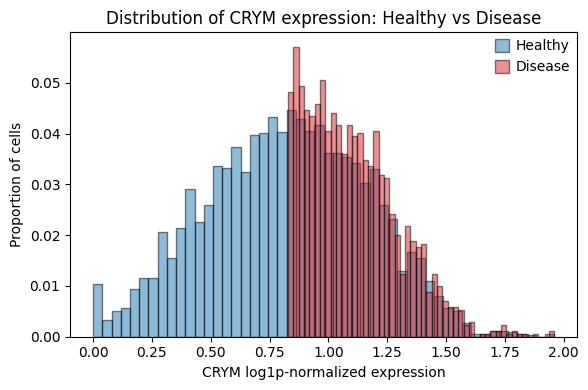

In [13]:
import numpy as np

# "Healthy" = full donor s5 object (all cells)
crym_expr_healthy = sc.get.obs_df(b_matrix_s1, keys=["CRYM"])["CRYM"]
crym_p50 = np.percentile(crym_expr_healthy, 50)

# "Disease" = new object keeping only the top 50% of cells by CRYM expression
b_matrix_s1_disease = b_matrix_s1[crym_expr_healthy >= crym_p50].copy()
crym_expr_disease = sc.get.obs_df(b_matrix_s1_disease, keys=["CRYM"])["CRYM"]

print(f"Healthy: {b_matrix_s1.n_obs} cells")
print(f"Disease (CRYM >= 50th percentile = {crym_p50:.3f}): {b_matrix_s1_disease.n_obs} cells")

# Distribution of CRYM expression: x = CRYM log value, y = proportion of cells in that sample
weights_healthy = np.ones_like(crym_expr_healthy) / len(crym_expr_healthy)
weights_disease = np.ones_like(crym_expr_disease) / len(crym_expr_disease)

plt.figure(figsize=(6, 4))
plt.hist(crym_expr_healthy, bins=50, weights=weights_healthy, alpha=0.5, label="Healthy", color="#1f77b4", edgecolor="black")
plt.hist(crym_expr_disease, bins=50, weights=weights_disease, alpha=0.5, label="Disease", color="#d62728", edgecolor="black")
plt.xlabel("CRYM log1p-normalized expression")
plt.ylabel("Proportion of cells")
plt.title("Distribution of CRYM expression: Healthy vs Disease")
plt.legend()
plt.tight_layout()
plt.savefig("./img/crym_expression_healthy_vs_disease.png", dpi=300, bbox_inches='tight')
plt.show()


Healthy (BICAN, donor s5, Matrix_D1): 3396 cells
Disease (SlideTag, sample_02, Matrix_D1): 3087 cells


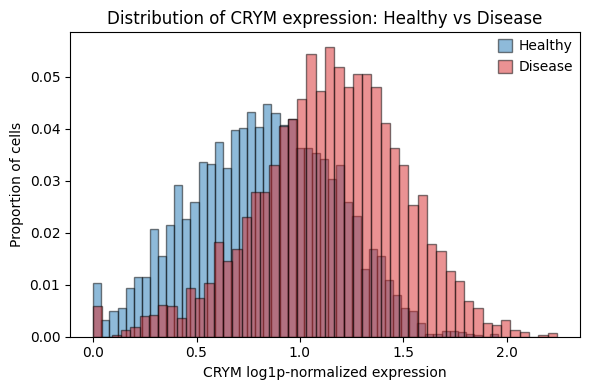

In [14]:
import numpy as np

# "Healthy" = BICAN donor s5, Matrix_D1 (already log1p-normalized in b_matrix_s1)
crym_expr_healthy = sc.get.obs_df(b_matrix_s1, keys=["CRYM"])["CRYM"]

# "Disease" = SlideTag sample_02, subset to Matrix_D1
slidetag_disease = slidetag[
    (slidetag.obs['sample'] == 'sample_02') & (slidetag.obs['ct_for_deg'] == 'Matrix_D1')
].copy()

slidetag_disease.var.index = slidetag_disease.var["gene_symbol"].astype(str)
slidetag_disease.var_names_make_unique()

crym_expr_disease = sc.get.obs_df(slidetag_disease, keys=["CRYM"], layer="log1p_norm")["CRYM"]

print(f"Healthy (BICAN, donor s5, Matrix_D1): {b_matrix_s1.n_obs} cells")
print(f"Disease (SlideTag, sample_02, Matrix_D1): {slidetag_disease.n_obs} cells")

# Distribution of CRYM expression: x = CRYM log value, y = proportion of cells in that sample
weights_healthy = np.ones_like(crym_expr_healthy) / len(crym_expr_healthy)
weights_disease = np.ones_like(crym_expr_disease) / len(crym_expr_disease)

plt.figure(figsize=(6, 4))
plt.hist(crym_expr_healthy, bins=50, weights=weights_healthy, alpha=0.5, label="Healthy", color="#1f77b4", edgecolor="black")
plt.hist(crym_expr_disease, bins=50, weights=weights_disease, alpha=0.5, label="Disease", color="#d62728", edgecolor="black")
plt.xlabel("CRYM log1p-normalized expression")
plt.ylabel("Proportion of cells")
plt.title("Distribution of CRYM expression: Healthy vs Disease")
plt.legend()
plt.tight_layout()
plt.savefig("./img/crym_expression_healthy_vs_disease.png", dpi=300, bbox_inches='tight')
plt.show()


# DA

In [1]:
import pandas as pd

In [20]:
str_allcells_ctfordeg = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/ct_for_deg/crumblr_results.csv")
#str_allcells_ctfordeg = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_neurons/ct_for_deg/crumblr_results.csv")
# str_allcells_ctfordeg = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/Group_name/crumblr_results.csv")


str_allcells_ctfordeg

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient
0,0.363920,-1.185196,1.277173,2.080176e-01,3.200270e-01,-6.154843,-TAFA1,conditionXDP
1,0.610490,2.493177,3.856666,3.592881e-04,1.405762e-03,-0.213412,Astrocyte,conditionXDP
2,0.017461,-1.635961,0.092781,9.264848e-01,9.416802e-01,-6.833712,COP,conditionXDP
3,0.316593,-1.197604,1.594592,1.177243e-01,2.140443e-01,-5.583042,Endothelial_BBB,conditionXDP
4,1.178487,-0.814276,3.804430,4.217285e-04,1.405762e-03,-0.575001,Ependymal,conditionXDP
5,0.505434,-2.335283,2.291675,2.660172e-02,6.650430e-02,-4.197938,Fibroblasts,conditionXDP
6,0.316728,-2.146604,1.157496,2.531075e-01,3.454451e-01,-6.286835,Lymphocyte,conditionXDP
7,0.552307,-1.086519,3.681475,6.127183e-04,1.750624e-03,-0.819075,Macrophages,conditionXDP
8,-1.229350,1.313178,-7.140020,5.944049e-09,5.944049e-08,10.301741,Matrix_D1,conditionXDP
9,-1.324142,1.390548,-7.363726,2.763367e-09,5.526733e-08,11.033958,Matrix_D2,conditionXDP


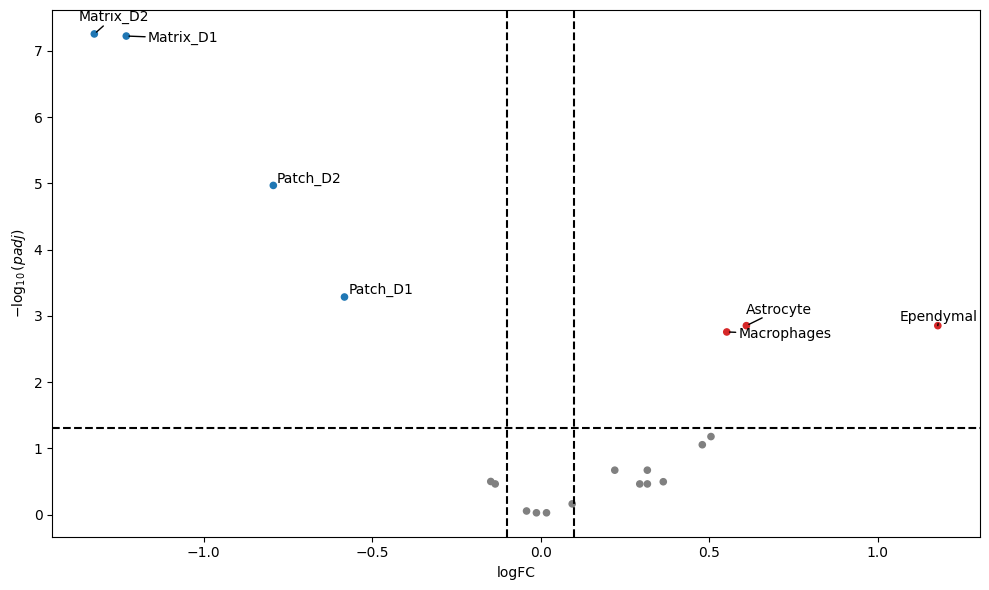

In [21]:
import decoupler as dc

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

dc.pl.volcano(
    str_allcells_ctfordeg.set_index("cell_type").rename(columns={"adj.P.Val": "padj", "logFC": "logFC"}), # ccan manage "_"
    x="logFC",
    y="padj",
    top=40,
    thr_stat=0.1, # logFC thresholdFORCE TO SEE ALL
    thr_sign=0.05, # p-value threshold',
    max_stat=6,        # clip x-axis to ± 5
    figsize=(10, 6)
)

# SlideTag - Patch Spared

... storing 'matrix_vs_patch' as categorical
... storing 'D1_vs_D2' as categorical
... storing 'matrix_vs_patch' as categorical
... storing 'D1_vs_D2' as categorical
... storing 'matrix_vs_patch' as categorical
... storing 'D1_vs_D2' as categorical


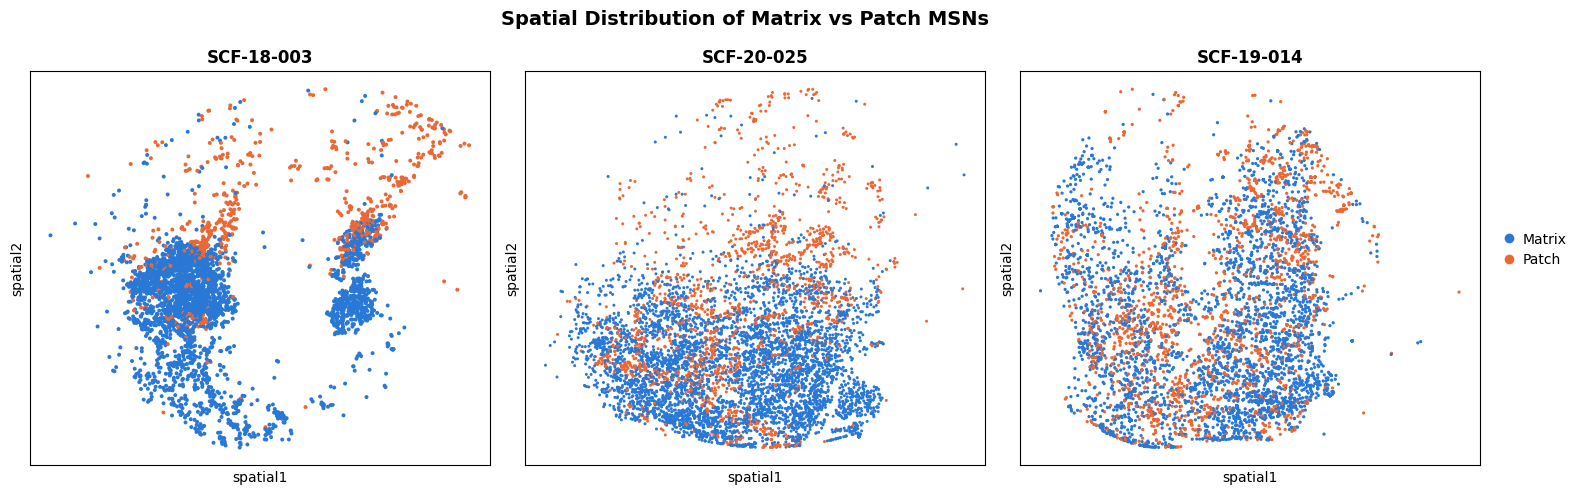

In [59]:
samples = ["sample_01", "sample_02", "sample_03"]
palette = {"Matrix": "#2a78d6", "Patch": "#eb6834"}  # fixed so colors match across panels

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))

for ax, s in zip(axes, samples):
    tmp = slidetag[
        (slidetag.obs['sample'] == s) &
        (slidetag.obs['ct_for_deg'].isin(MSN_ct)) &
        (slidetag.obs['has_spatial']) &
        (slidetag.obs['matrix_vs_patch'].notna())
    ].copy()

    d = tmp.obs["donor_id"].unique().tolist()[0]

    sc.pl.embedding(
        tmp,
        basis='spatial',
        color="matrix_vs_patch",
        palette=palette,
        ax=ax,
        show=False,
        frameon=True,
        legend_loc=None,
    )
    ax.set_title(d, fontsize=12, fontweight='bold')

# one shared legend for the whole row
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=lbl)
           for lbl, c in palette.items()]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

fig.suptitle("Spatial Distribution of Matrix vs Patch MSNs", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("./img/spatial_matrix_vs_patch_all_samples.png", dpi=300, bbox_inches='tight')
plt.show()


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'matrix_vs_patch' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'D1_vs_D2' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'matrix_vs_patch' as cate

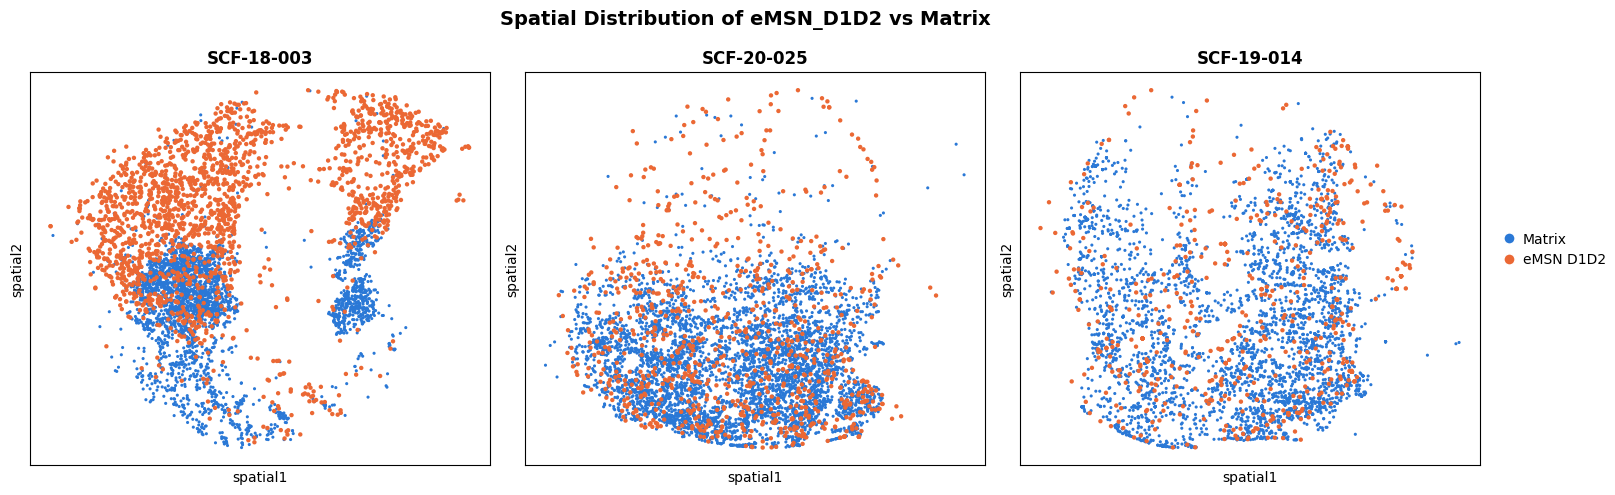

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

# ============================================================================
# Build binary highlight column: eMSN_D1D2 vs everything else
# ============================================================================
slidetag.obs["d1d2_highlight"] = pd.Series(
    np.where(slidetag.obs["ct_for_deg"] == "eMSN_D1D2", "eMSN D1D2", "Matrix"),
    index=slidetag.obs.index,
).astype("category")

slidetag.obs["d1d2_highlight"] = slidetag.obs["d1d2_highlight"].cat.set_categories(["Matrix", "eMSN D1D2"])

palette = {"Matrix": "#2a78d6", "eMSN D1D2": "#eb6834"}  # fixed so colors match across panels

size_rest = 20
size_highlight = 40

# ============================================================================
# One row, one panel per sample: background cells small, eMSN_D1D2 big + on top
# ============================================================================
samples = ["sample_01", "sample_02", "sample_03"]
fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))

for ax, s in zip(axes, samples):
    tmp = slidetag[
        (slidetag.obs['sample'] == s) &
        (slidetag.obs['ct_for_deg'].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])) &
        (slidetag.obs['has_spatial'])
    ].copy()

    tmp_rest = tmp[tmp.obs["d1d2_highlight"] == "Matrix"]
    tmp_d1d2 = tmp[tmp.obs["d1d2_highlight"] == "eMSN D1D2"]

    d = tmp.obs["donor_id"].unique().tolist()[0]

    sc.pl.embedding(
        tmp_rest,
        basis='spatial',
        color="d1d2_highlight",
        palette=palette,
        ax=ax,
        show=False,
        frameon=True,
        legend_loc=None,
        size=size_rest,
    )
    sc.pl.embedding(
        tmp_d1d2,
        basis='spatial',
        color="d1d2_highlight",
        palette=palette,
        ax=ax,
        show=False,
        frameon=True,
        legend_loc=None,
        size=size_highlight,
    )
    ax.set_title(d, fontsize=12, fontweight='bold')

# Shared legend for the whole row
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=lbl)
    for lbl, c in palette.items()
]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

fig.suptitle("Spatial Distribution of eMSN_D1D2 vs Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("./img/spatial_d1d2_highlight_all_samples.png", dpi=300, bbox_inches='tight')
plt.show()


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'matrix_vs_patch' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'D1_vs_D2' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'matrix_vs_patch' as categorical
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'D1_vs_D2' as catego

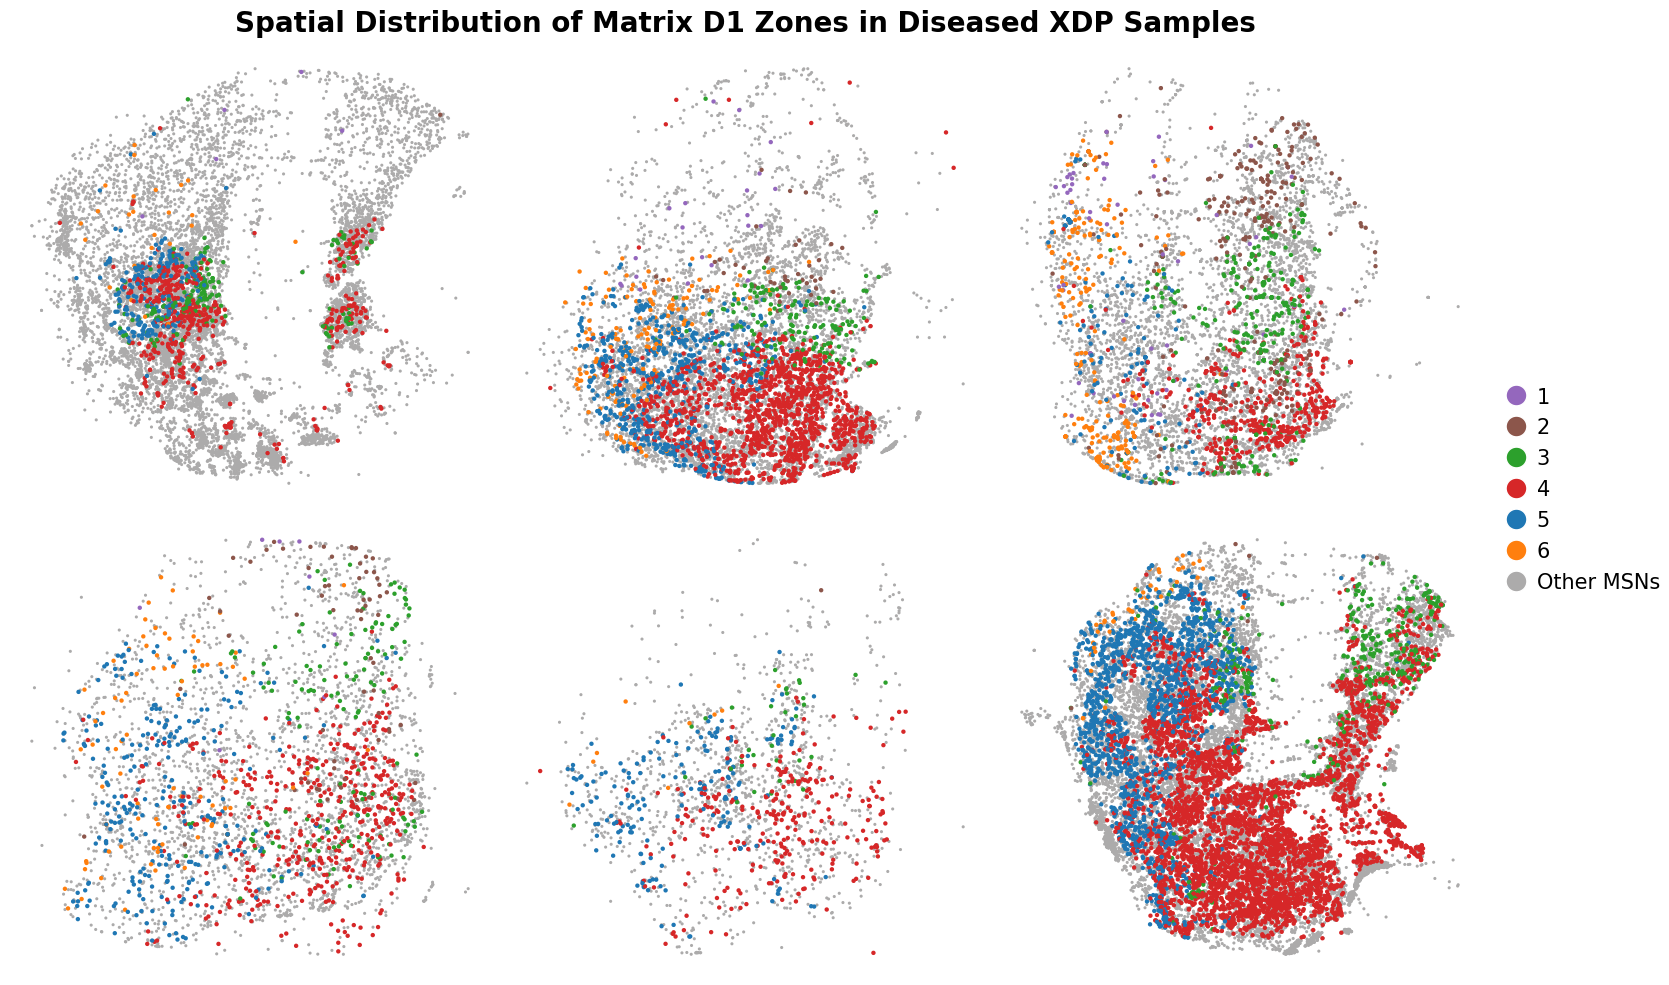

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

# ============================================================================
# Build zone column: real zone for Matrix_D1, "Other MSNs" for eMSN_D1D2 / Matrix_D2
# ============================================================================
slidetag.obs["Matrix D1 Zones"] = pd.Series(
    np.where(slidetag.obs["ct_for_deg"] == "Matrix_D1", slidetag.obs["zone"], "Other MSNs"),
    index=slidetag.obs.index,
).astype("category")

zone_order = [z for z in ["1", "2", "3", "4", "5", "6"] if z in slidetag.obs["Matrix D1 Zones"].cat.categories]
slidetag.obs["Matrix D1 Zones"] = slidetag.obs["Matrix D1 Zones"].cat.set_categories(zone_order + ["Other MSNs"])

palette_zones = {**palette_zones, "Other MSNs": "#ACABAB"}  # palette_zones from the PALETTE env var, set earlier

size_rest = 20
size_highlight = 40

# ============================================================================
# One row, one panel per sample: MSN cells colored by Matrix D1 zone
# ============================================================================
samples = ["sample_01", "sample_02", "sample_03", "sample_04", "sample_06", "sample_09"]
fig, axes = plt.subplots(2, 3, figsize=(5 * 3, 10))

for ax, s in zip(axes.flatten(), samples):
    tmp = slidetag[
        (slidetag.obs['sample'] == s) &
        (slidetag.obs['ct_for_deg'].isin(MSN_ct)) &
        (slidetag.obs['has_spatial'])
    ].copy()

    tmp_rest = tmp[tmp.obs["Matrix D1 Zones"] == "Other MSNs"]
    tmp_zone = tmp[tmp.obs["Matrix D1 Zones"] != "Other MSNs"]

    #d = tmp.obs["donor_id"].unique().tolist()[0]

    sc.pl.embedding(
        tmp_rest,
        basis='spatial',
        color="Matrix D1 Zones",
        palette=palette_zones,
        ax=ax,
        show=False,
        legend_loc=None,
        size=size_rest,
        frameon=False
    )
    sc.pl.embedding(
        tmp_zone,
        basis='spatial',
        color="Matrix D1 Zones",
        palette=palette_zones,
        ax=ax,
        show=False,
        legend_loc=None,
        size=size_highlight,
        frameon=False
    )
    ax.set_title("", fontsize=12, fontweight='bold')

# Shared legend for the whole row
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=15, label=lbl)
    for lbl, c in palette_zones.items()
    if lbl in slidetag.obs["Matrix D1 Zones"].cat.categories
]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=15)

fig.suptitle("Spatial Distribution of Matrix D1 Zones in Diseased XDP Samples", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("./img/spatial_matrixD1_zone_all_samples.png", dpi=300, bbox_inches='tight')
plt.show()


# Zones 

In [35]:
import json
import os

palette_zones = json.loads(os.getenv("PALETTE"))


In [11]:
tmp = slidetag[
    (slidetag.obs['sample'] == 'sample_02') &
    (slidetag.obs['ct_for_deg'].isin(MSN_ct)) &
    (slidetag.obs['has_spatial'])
].copy()

In [33]:
tmp.obs["Matrix D1 Zones"] = pd.Series(
    np.where(tmp.obs["ct_for_deg"] == "Matrix_D1", tmp.obs["zone"], "Other MSNs"),
    index=tmp.obs.index,
).astype("category")

tmp.obs["Matrix D1 Zones"] = tmp.obs["Matrix D1 Zones"].cat.set_categories(["1", "2", "3", "4", "5", "6", "Other MSNs"])

palette_zones = {**palette_zones, "Other MSNs": "#D3D3D3"}

<Axes: title={'center': 'Matrix D1 Zones'}, xlabel='spatial1', ylabel='spatial2'>

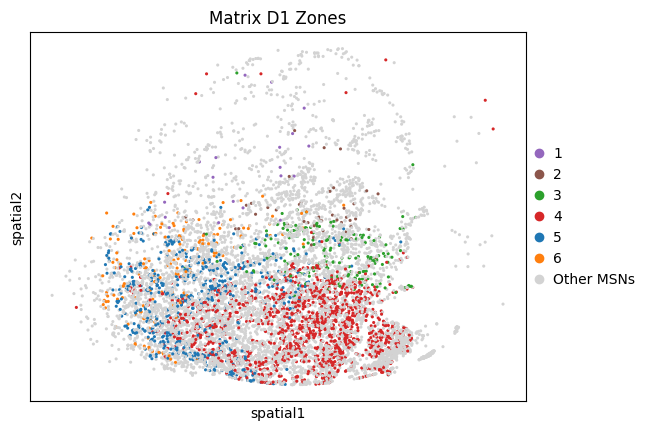

In [ ]:
sc.pl.embedding(
    tmp,
    basis='spatial',
    color="Matrix D1 Zones",
    show=False,
    frameon=True,
    size=20,
    palette=palette_zones,
)